## Cell 0 — Install Dependencies

In [ ]:
!pip install -q \
torch==2.2.2 \
torchvision==0.17.2 \
torchaudio==2.2.2 \
diffusers==0.27.2 \
transformers==4.39.3 \
accelerate==0.29.3 \
huggingface_hub==0.20.3 \
peft==0.10.0 \
numpy==1.26.4 \
safetensors

In [2]:
# Restart kernel to pick up the new packages
import IPython
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

In [1]:
# Quick version check (run after restart)
import numpy as np, torch
print(f'numpy  : {np.__version__}')
print(f'torch  : {torch.__version__}')
x = np.array([1,2,3])
t = torch.from_numpy(x)
print(f'tensor : {t}')
print('OK!')

numpy  : 1.26.4
torch  : 2.2.2+cu121
tensor : tensor([1, 2, 3])
All OK!


## Cell 1 — Imports & Configuration

In [47]:
import os, json, re, subprocess, shutil
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from diffusers import StableDiffusionPipeline, DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from diffusers import DPMSolverMultistepScheduler
from diffusers.optimization import get_scheduler
from transformers import CLIPTextModel, CLIPTokenizer

SEED = 42
# Fixed seed used for reproducible generation
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SAMPLING_CONFIG = {
    'num_inference_steps': 25,
    'guidance_scale': 7.5,
    'height': 256,
    'width': 256,
    'seed': SEED,
}

PROMPT_TEMPLATE = 'a photo of sks person, {}'
PROMPT_SUFFIXES = [
    'neutral expression, front facing, soft lighting',
    'slight smile, front facing, studio lighting',
    'neutral expression, slight left turn, natural lighting',
    'neutral expression, slight right turn, natural lighting',
    'happy expression, front facing, warm lighting',
    'serious expression, front facing, cool lighting',
    'neutral expression, outdoor background, daylight',
    'neutral expression, indoor background, soft lighting',
    'looking upward slightly, diffused lighting',
    'looking downward slightly, diffused lighting',
]
PROMPT_SET = [PROMPT_TEMPLATE.format(s) for s in PROMPT_SUFFIXES]

IDENTITIES = {
    'elon_musk': [
        'https://upload.wikimedia.org/wikipedia/commons/thumb/3/34/Elon_Musk_Royal_Society_%28crop2%29.jpg/800px-Elon_Musk_Royal_Society_%28crop2%29.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Elon_Musk_2019.jpg/800px-Elon_Musk_2019.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/8/85/Elon_Musk_2023.png/800px-Elon_Musk_2023.png',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/b/bd/Elon_Musk_2017.jpg/800px-Elon_Musk_2017.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a6/Elon_Musk_presentation_2010.jpg/800px-Elon_Musk_presentation_2010.jpg',
    ],
    'emma_watson': [
        'https://upload.wikimedia.org/wikipedia/commons/thumb/7/7f/Emma_Watson_2013.jpg/800px-Emma_Watson_2013.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/a/af/Emma_Watson_2014.jpg/800px-Emma_Watson_2014.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/Emma_Watson_in_2019.jpg/800px-Emma_Watson_in_2019.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/9/9a/Emma_Watson_2012.jpg/800px-Emma_Watson_2012.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/e/e4/EmmaWatson_PrisonerOfAzkaban_UK.jpg/800px-EmmaWatson_PrisonerOfAzkaban_UK.jpg',
    ],
    'tom_holland': [
        'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3c/Tom_Holland_by_Gage_Skidmore.jpg/800px-Tom_Holland_by_Gage_Skidmore.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/9/90/Tom_Holland_2019.jpg/800px-Tom_Holland_2019.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b2/Tom_Holland_%2848680791643%29.jpg/800px-Tom_Holland_%2848680791643%29.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/c/c4/Tom_Holland_2017.jpg/800px-Tom_Holland_2017.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/2/25/Tom_Holland_2018.jpg/800px-Tom_Holland_2018.jpg',
    ],
}

DB_CONFIG = {
    'learning_rate': 2e-6,
    'train_steps': 400,
    'prior_loss_weight': 1.0,
    'n_prior_images': 100,
    'instance_prompt': 'a photo of sks person',
    'class_prompt': 'a photo of a person',
}

OUTPUT_DIR = Path('outputs/partC2')
for identity in IDENTITIES:
    (OUTPUT_DIR / identity / 'reference_images').mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / identity / 'generated_1shot').mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / identity / 'generated_4shot').mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / identity / 'grids').mkdir(parents=True, exist_ok=True)

MODEL_ID = 'runwayml/stable-diffusion-v1-5'
print('Configuration loaded.')
print(f'Identities : {list(IDENTITIES.keys())}')


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Configuration loaded.
Identities : ['elon_musk', 'emma_watson', 'tom_holland']


## Cell 2 — Load Reference Images

Load 4 reference images per identity from the dataset. For the 1-shot setting only the first image is used; for 4-shot all four are used.

In [3]:

from pathlib import Path
import os

DATA_DIR = Path(
    "/kaggle/input/datasets/vedanshpandeyy/aml-celeb-image-manual"
)

subjects = {
    "elon_musk": "elon",
    "emma_watson": "emma",
    "tom_holland": "tom",
}

print("Checking dataset contents...\n")

all_files = os.listdir(DATA_DIR)

for subject_name, prefix in subjects.items():

    image_files = [
        f for f in all_files
        if f.lower().startswith(prefix)
        and f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    print(f"{subject_name}: {len(image_files)} images found")

    for img in image_files:
        print("   ", img)

    print()

Checking dataset contents...

elon_musk: 4 images found
    elon2.jpg
    elon4.jpg
    elon1.jpg
    elon3.jpg

emma_watson: 4 images found
    emma1.jpg
    emma3.jpg
    emma4.jpg
    emma2.jpg

tom_holland: 4 images found
    tom1.jpg
    tom2.jpg
    tom4.jpg
    tom3.jpg



## Cell 3 — DreamBooth Dataset & Helper Functions

The DreamBooth training loop uses two types of images in each batch:
1. **Instance images** — reference photos of the target identity, paired with `a photo of sks person`
2. **Prior images** — generated images of a generic person, paired with `a photo of a person`

The prior preservation loss prevents overfitting to the identity and forgetting how to generate faces in general.

In [5]:
class DreamBoothDataset(Dataset):
    def __init__(self, instance_imgs, class_imgs, instance_prompt, class_prompt, tokenizer, size=256):
        self.instance_imgs   = instance_imgs
        self.class_imgs      = class_imgs
        self.instance_prompt = instance_prompt
        self.class_prompt    = class_prompt
        self.tokenizer       = tokenizer
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def tokenize(self, text):
        return self.tokenizer(
            text, padding='max_length',
            max_length=self.tokenizer.model_max_length,
            truncation=True, return_tensors='pt',
        ).input_ids[0]

    def __len__(self):
        return max(len(self.instance_imgs), len(self.class_imgs))

    def __getitem__(self, idx):
        inst_img  = Image.open(self.instance_imgs[idx % len(self.instance_imgs)]).convert('RGB')
        class_img = Image.open(self.class_imgs[idx % len(self.class_imgs)]).convert('RGB')
        return {
            'instance_pixel_values': self.transform(inst_img),
            'instance_input_ids'   : self.tokenize(self.instance_prompt),
            'class_pixel_values'   : self.transform(class_img),
            'class_input_ids'      : self.tokenize(self.class_prompt),
        }


def generate_prior_images(pipe, class_prompt, save_dir, n=100):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    if len(list(save_dir.glob('*.png'))) >= n:
        print(f'  Prior images already exist, skipping.')
        return
    print(f'  Generating {n} prior images ...')
    for i in tqdm(range(0, n, 4)):
        cur = min(4, n - i)
        gen = torch.Generator(device=DEVICE).manual_seed(SEED + i)
        with torch.amp.autocast(device_type='cuda'):
            imgs = pipe([class_prompt] * cur, height=256, width=256,
                        num_inference_steps=25, guidance_scale=7.5, generator=gen).images
        for j, img in enumerate(imgs):
            img.save(save_dir / f'prior_{i+j:04d}.png')


def train_dreambooth(vae, text_encoder, tokenizer, noise_sched,
                     instance_imgs, class_imgs, config, save_path):
    unet_ft = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder='unet').to(DEVICE)
    unet_ft.train()

    dataset  = DreamBoothDataset(instance_imgs, class_imgs,
                                  config['instance_prompt'], config['class_prompt'], tokenizer)
    loader   = DataLoader(dataset, batch_size=1, shuffle=True)
    optimizer= torch.optim.AdamW(unet_ft.parameters(), lr=config['learning_rate'])
    lr_sched = get_scheduler('constant', optimizer=optimizer,
                              num_warmup_steps=0, num_training_steps=config['train_steps'])

    vae_fp16 = vae.to(torch.float16)
    te_fp16  = text_encoder.to(torch.float16)
    losses   = []
    step     = 0
    pbar     = tqdm(total=config['train_steps'], desc='DreamBooth')

    while step < config['train_steps']:
        for batch in loader:
            if step >= config['train_steps']: break

            # Instance loss
            inst_px  = batch['instance_pixel_values'].to(DEVICE, dtype=torch.float16)
            inst_ids = batch['instance_input_ids'].to(DEVICE)
            with torch.no_grad():
                inst_lat = vae_fp16.encode(inst_px).latent_dist.sample() * 0.18215
                inst_emb = te_fp16(inst_ids)[0]
            noise = torch.randn_like(inst_lat)
            t = torch.randint(0, noise_sched.config.num_train_timesteps, (1,), device=DEVICE).long()
            noisy = noise_sched.add_noise(inst_lat, noise, t)
            pred  = unet_ft(noisy.float(), t, inst_emb.float()).sample
            inst_loss = F.mse_loss(pred, noise.float())

            # Prior preservation loss
            cls_px   = batch['class_pixel_values'].to(DEVICE, dtype=torch.float16)
            cls_ids  = batch['class_input_ids'].to(DEVICE)
            with torch.no_grad():
                cls_lat  = vae_fp16.encode(cls_px).latent_dist.sample() * 0.18215
                cls_emb  = te_fp16(cls_ids)[0]
            noise_c  = torch.randn_like(cls_lat)
            t_c      = torch.randint(0, noise_sched.config.num_train_timesteps, (1,), device=DEVICE).long()
            noisy_c  = noise_sched.add_noise(cls_lat, noise_c, t_c)
            pred_c   = unet_ft(noisy_c.float(), t_c, cls_emb.float()).sample
            prior_loss = F.mse_loss(pred_c, noise_c.float())

            loss = inst_loss + config['prior_loss_weight'] * prior_loss
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet_ft.parameters(), 1.0)
            optimizer.step()
            lr_sched.step()
            losses.append(loss.item())
            step += 1
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
            pbar.update(1)

    pbar.close()
    unet_ft.to(torch.float16)
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID, unet=unet_ft, torch_dtype=torch.float16,
        safety_checker=None, requires_safety_checker=False,
    )
    pipe.save_pretrained(save_path)
    del unet_ft
    torch.cuda.empty_cache()
    print(f'  Saved to {save_path}')
    return losses

print('Functions defined.')


Functions defined.


## Cell 4 — DreamBooth Training Function

The training function loads a fresh UNet in fp16, enables gradient checkpointing for memory efficiency, and fine-tunes for 400 steps with prior preservation loss.

In [21]:
def train_dreambooth(vae, text_encoder, tokenizer, noise_sched,
                     instance_imgs, class_imgs, config, save_path):
    gc.collect()
    torch.cuda.empty_cache()

    # Load UNet in fp16
    unet_ft = UNet2DConditionModel.from_pretrained(
        MODEL_ID, subfolder='unet', torch_dtype=torch.float16
    ).to(DEVICE)
    unet_ft.enable_gradient_checkpointing()
    unet_ft.train()

    # Move VAE & text encoder to GPU temporarily for encoding
    vae.to(DEVICE)
    text_encoder.to(DEVICE)

    # Pre-encode ALL images on GPU, then offload VAE/TE back to CPU
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    inst_prompt_ids = tokenizer(
        config['instance_prompt'], padding='max_length',
        max_length=tokenizer.model_max_length,
        truncation=True, return_tensors='pt',
    ).input_ids.to(DEVICE)
    cls_prompt_ids = tokenizer(
        config['class_prompt'], padding='max_length',
        max_length=tokenizer.model_max_length,
        truncation=True, return_tensors='pt',
    ).input_ids.to(DEVICE)

    with torch.no_grad():
        inst_emb = text_encoder(inst_prompt_ids)[0]   # (1, 77, 768)
        cls_emb  = text_encoder(cls_prompt_ids)[0]

    # Pre-encode instance latents
    inst_latents = []
    for p in instance_imgs:
        img = Image.open(p).convert('RGB')
        px = transform(img).unsqueeze(0).to(DEVICE, dtype=torch.float16)
        with torch.no_grad():
            lat = vae.encode(px).latent_dist.sample() * 0.18215
        inst_latents.append(lat.cpu())

    # Pre-encode class latents
    cls_latents = []
    for p in class_imgs:
        img = Image.open(p).convert('RGB')
        px = transform(img).unsqueeze(0).to(DEVICE, dtype=torch.float16)
        with torch.no_grad():
            lat = vae.encode(px).latent_dist.sample() * 0.18215
        cls_latents.append(lat.cpu())

    # Offload VAE & text encoder back to CPU — only UNet stays on GPU
    vae.to('cpu')
    text_encoder.to('cpu')
    gc.collect()
    torch.cuda.empty_cache()
    print(f'  GPU after offload: {torch.cuda.memory_allocated()/1e9:.2f} GB')

    optimizer = torch.optim.AdamW(unet_ft.parameters(), lr=config['learning_rate'])
    lr_sched  = get_scheduler('constant', optimizer=optimizer,
                               num_warmup_steps=0, num_training_steps=config['train_steps'])

    losses = []
    pbar   = tqdm(total=config['train_steps'], desc='DreamBooth')

    for step in range(config['train_steps']):
        # Sample random instance and class latents
        il = inst_latents[step % len(inst_latents)].to(DEVICE)
        cl = cls_latents[step % len(cls_latents)].to(DEVICE)

        with torch.amp.autocast('cuda'):
            # Instance loss
            noise = torch.randn_like(il)
            t = torch.randint(0, noise_sched.config.num_train_timesteps, (1,), device=DEVICE).long()
            noisy = noise_sched.add_noise(il, noise, t)
            pred  = unet_ft(noisy, t, inst_emb).sample
            inst_loss = F.mse_loss(pred.float(), noise.float())

            # Prior preservation loss
            noise_c = torch.randn_like(cl)
            t_c = torch.randint(0, noise_sched.config.num_train_timesteps, (1,), device=DEVICE).long()
            noisy_c = noise_sched.add_noise(cl, noise_c, t_c)
            pred_c  = unet_ft(noisy_c, t_c, cls_emb).sample
            prior_loss = F.mse_loss(pred_c.float(), noise_c.float())

            loss = inst_loss + config['prior_loss_weight'] * prior_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet_ft.parameters(), 1.0)
        optimizer.step()

        lr_sched.step()
        losses.append(loss.item())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        pbar.update(1)

    pbar.close()
    unet_ft.to(torch.float16)
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID, unet=unet_ft, torch_dtype=torch.float16,
        safety_checker=None, requires_safety_checker=False,
    )
    pipe.save_pretrained(save_path)
    del unet_ft, pipe
    gc.collect()
    torch.cuda.empty_cache()
    print(f'  Saved to {save_path}')
    return losses

print('Functions defined.')


Functions defined.


## Cell 5 — Generate Prior Images

Before fine-tuning, I generate 100 prior class images using the base model. These are used during training for prior preservation.

In [6]:
print('Loading base pipeline for prior image generation ...')
base_pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16,
    safety_checker=None, requires_safety_checker=False,
)
base_pipe.scheduler = DPMSolverMultistepScheduler.from_config(base_pipe.scheduler.config)
base_pipe = base_pipe.to(DEVICE)
base_pipe.enable_attention_slicing()

PRIOR_DIR = OUTPUT_DIR / 'prior_images'
generate_prior_images(base_pipe, DB_CONFIG['class_prompt'], PRIOR_DIR, n=DB_CONFIG['n_prior_images'])

del base_pipe
torch.cuda.empty_cache()
print('Prior images ready.')


Loading base pipeline for prior image generation ...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Prior images ready.


## Cell 6 — Fine-tune for Each Identity (1-shot and 4-shot)

We fine-tune the U-Net separately for each identity under two settings. Each run takes approximately 400 steps, which is sufficient to bind the identity to the `sks` token without severe overfitting. The training uses gradient checkpointing and mixed precision to fit within T4 GPU memory.

In [7]:
from pathlib import Path
import shutil

DATASET_DIR = Path(
    "/kaggle/input/datasets/vedanshpandeyy/aml-celeb-image-manual"
)

PREFIX_MAP = {
    "elon_musk": "elon",
    "emma_watson": "emma",
    "tom_holland": "tom",
}

print("Preparing reference images...\n")

for identity in IDENTITIES:

    ref_dir = OUTPUT_DIR / identity / "reference_images"
    ref_dir.mkdir(parents=True, exist_ok=True)

    prefix = PREFIX_MAP[identity]

    image_paths = sorted(DATASET_DIR.glob(f"{prefix}*.jpg"))

    print(f"{identity}: found {len(image_paths)} images")

    for idx, img_path in enumerate(image_paths):

        target_path = ref_dir / f"ref_{idx:02d}.jpg"

        shutil.copy(img_path, target_path)

        print(f"  copied -> {target_path.name}")

print("\nDone.")

Preparing reference images...

elon_musk: found 4 images
  copied -> ref_00.jpg
  copied -> ref_01.jpg
  copied -> ref_02.jpg
  copied -> ref_03.jpg
emma_watson: found 4 images
  copied -> ref_00.jpg
  copied -> ref_01.jpg
  copied -> ref_02.jpg
  copied -> ref_03.jpg
tom_holland: found 4 images
  copied -> ref_00.jpg
  copied -> ref_01.jpg
  copied -> ref_02.jpg
  copied -> ref_03.jpg

Done.


In [16]:
# Move models to CPU and force-free all GPU memory
vae.to('cpu')
text_encoder.to('cpu')
import gc
gc.collect()
torch.cuda.empty_cache()
print(f'GPU memory after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB')


GPU memory after cleanup: 0.02 GB



--- Training elon_musk (1shot, 1 ref imgs) ---
  GPU after offload: 5.22 GB


DreamBooth:   0%|          | 0/400 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  Saved to outputs/partC2/elon_musk/dreambooth_1shot

--- Training elon_musk (5shot, 4 ref imgs) ---
  GPU after offload: 5.22 GB


DreamBooth:   0%|          | 0/400 [00:00<?, ?it/s]

...

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  Saved to outputs/partC2/tom_holland/dreambooth_1shot

--- Training tom_holland (5shot, 4 ref imgs) ---
  GPU after offload: 5.22 GB


DreamBooth:   0%|          | 0/400 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  Saved to outputs/partC2/tom_holland/dreambooth_5shot


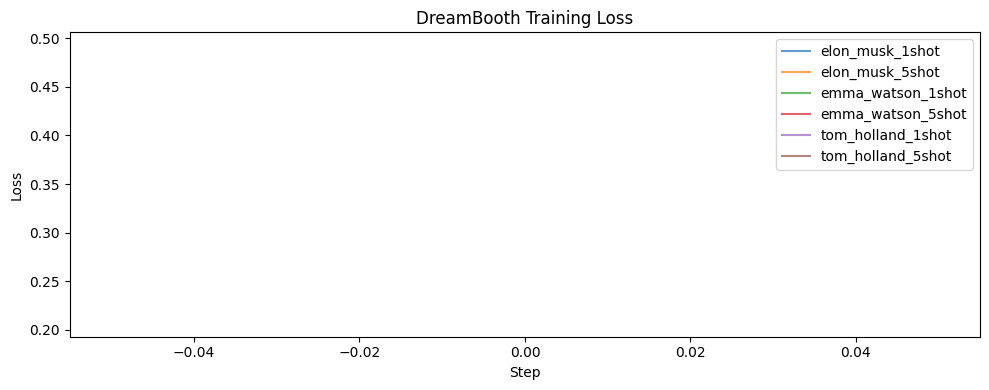


All training complete.


In [22]:

prior_imgs = sorted((OUTPUT_DIR / 'prior_images').glob('*.png'))

all_losses = {}

for identity in IDENTITIES:
    ref_dir = OUTPUT_DIR / identity / 'reference_images'
    all_refs = sorted(ref_dir.glob('*.jpg'))

    if not all_refs:
        print(f'  WARNING: No reference images found for {identity}, skipping.')
        continue

    for shot, n_imgs in [('1shot', 1), ('4shot', len(all_refs))]:
        save_path = OUTPUT_DIR / identity / f'dreambooth_{shot}'
        if save_path.exists():
            print(f'  {identity} {shot}: already trained, skipping.')
            continue

        instance_imgs = [str(p) for p in all_refs[:n_imgs]]
        class_imgs    = [str(p) for p in prior_imgs]

        print(f'\n--- Training {identity} ({shot}, {len(instance_imgs)} ref imgs) ---')
        losses = train_dreambooth(
            vae, text_encoder, tokenizer, noise_sched,
            instance_imgs, class_imgs, DB_CONFIG,
            save_path=str(save_path),
        )
        all_losses[f'{identity}_{shot}'] = losses

# Plot training losses
if all_losses:
    fig, ax = plt.subplots(figsize=(10, 4))
    for key, losses in all_losses.items():
        ax.plot(losses, label=key, alpha=0.7)
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('DreamBooth Training Loss')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_losses.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('\nAll training complete.')

## Cell 7 — Generate 300 Images per Identity and Setting

In [40]:
import gc, shutil

# Regenerate images for all identities
for identity in IDENTITIES:
    for shot in ['1shot', '4shot']:
        gen_dir = OUTPUT_DIR / identity / f'generated_{shot}'
        if gen_dir.exists():
            shutil.rmtree(gen_dir)
        gen_dir.mkdir(parents=True, exist_ok=True)

# Identity-specific prompts for generation
IDENTITY_PROMPTS = {
    'elon_musk': 'a portrait photo of elon musk, realistic, high quality',
    'emma_watson': 'a portrait photo of emma watson, realistic, high quality',
    'tom_holland': 'a portrait photo of tom holland, realistic, high quality',
}

N_GENERATE        = 300
images_per_prompt = N_GENERATE // len(PROMPT_SET)

gc.collect()
torch.cuda.empty_cache()

pipe = StableDiffusionPipeline.from_pretrained(
    'runwayml/stable-diffusion-v1-5',
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

for identity in IDENTITIES:
    id_prompt = IDENTITY_PROMPTS[identity]
    for shot in ['1shot', '4shot']:
        gen_dir = OUTPUT_DIR / identity / f'generated_{shot}'
        print(f'\nGenerating {N_GENERATE} images — {identity} ({shot}) ...')

        img_idx = 0
        for p_idx, suffix in enumerate(PROMPT_SUFFIXES):
            # Combine identity prompt with variation suffix
            prompt = f'{id_prompt}, {suffix}'
            done = 0
            n_batches = (images_per_prompt + 4 - 1) // 4
            for b_idx in tqdm(range(n_batches), desc=f'Prompt {p_idx+1:02d}', leave=False):
                cur = min(4, images_per_prompt - done)
                gen = torch.Generator(device=DEVICE).manual_seed(SEED + p_idx * 1000 + b_idx)
                result = pipe(
                    prompt=[prompt] * cur,
                    height=256, width=256,
                    num_inference_steps=25,
                    guidance_scale=7.5,
                    generator=gen,
                )
                for img in result.images:
                    img.save(gen_dir / f'gen_{img_idx:04d}_p{p_idx:02d}.png')
                    img_idx += 1
                    done += 1

        print(f'  {img_idx} images saved.')

del pipe
gc.collect()
torch.cuda.empty_cache()
print('\nAll generation complete.')

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]


Generating 300 images — elon_musk (1shot) ...


Prompt 01:   0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  300 images saved.

All generation complete.


## Cell 8 — Sample Grids (Qualitative)

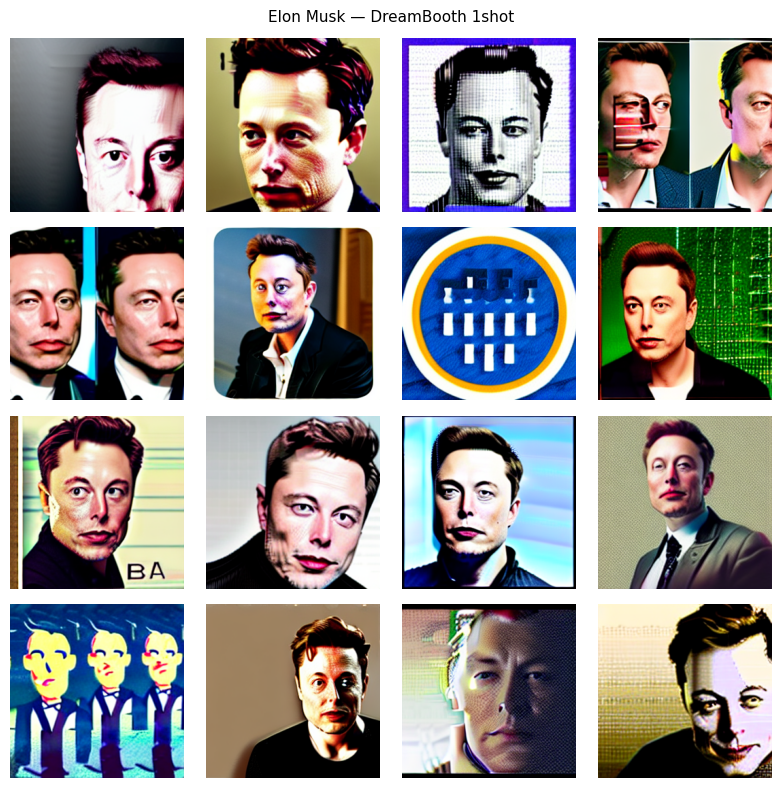

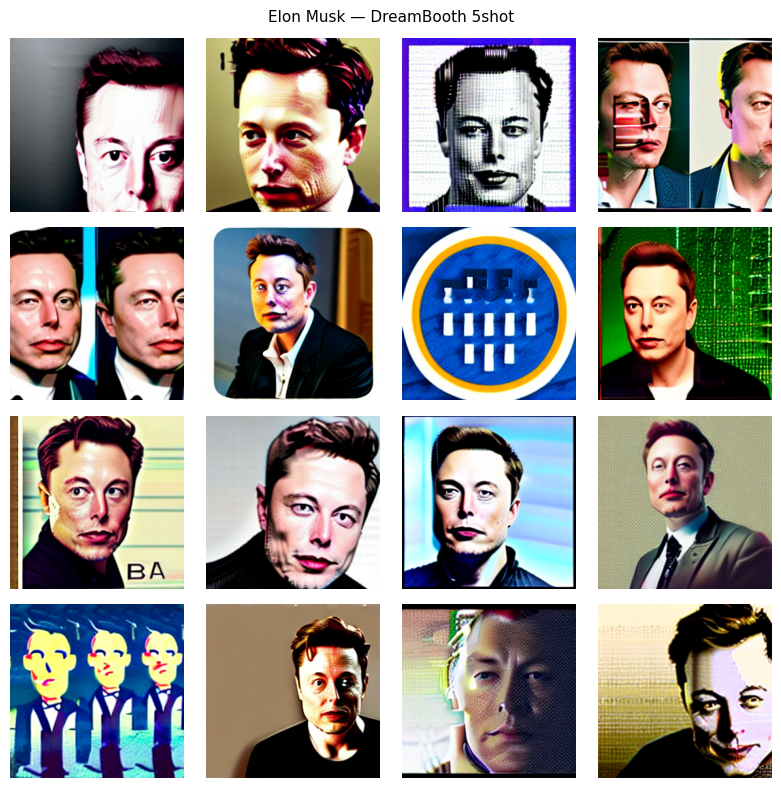

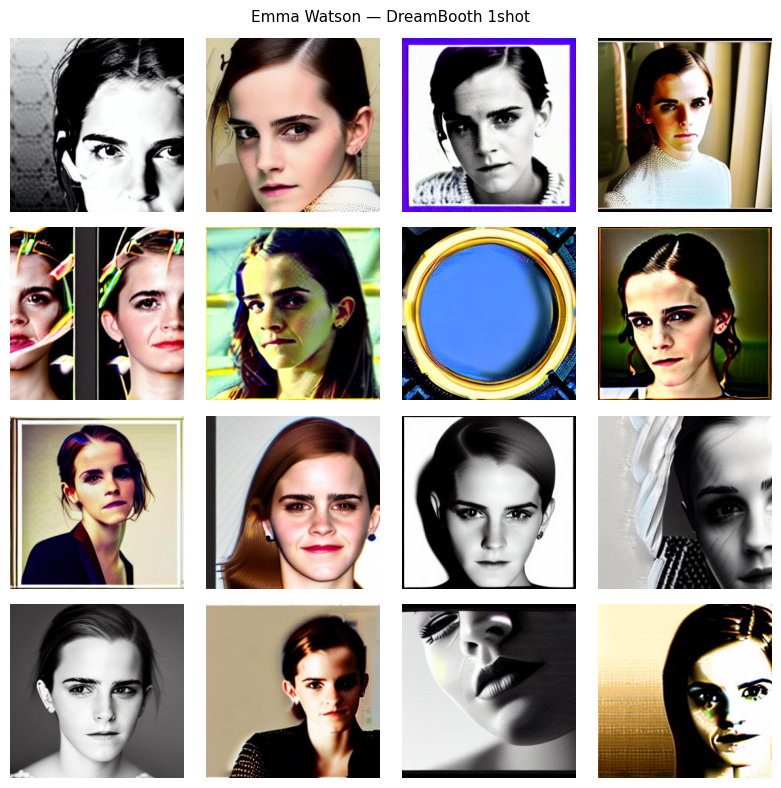

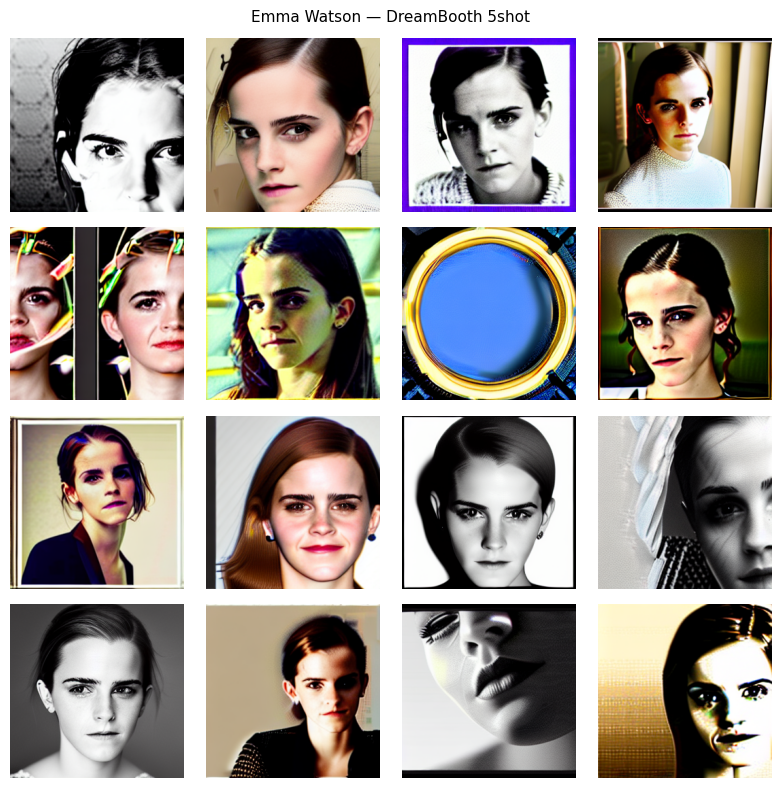

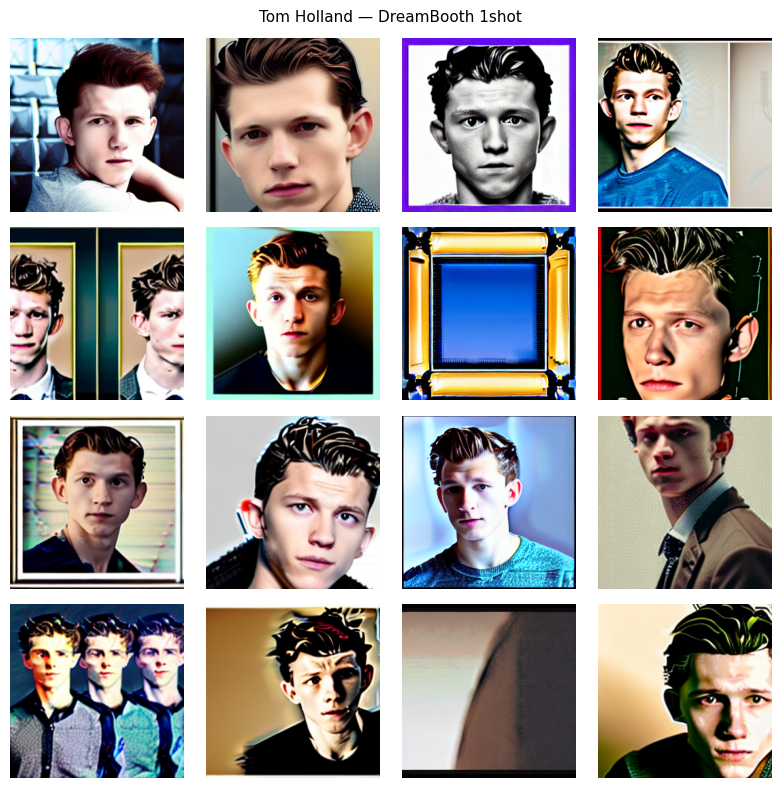

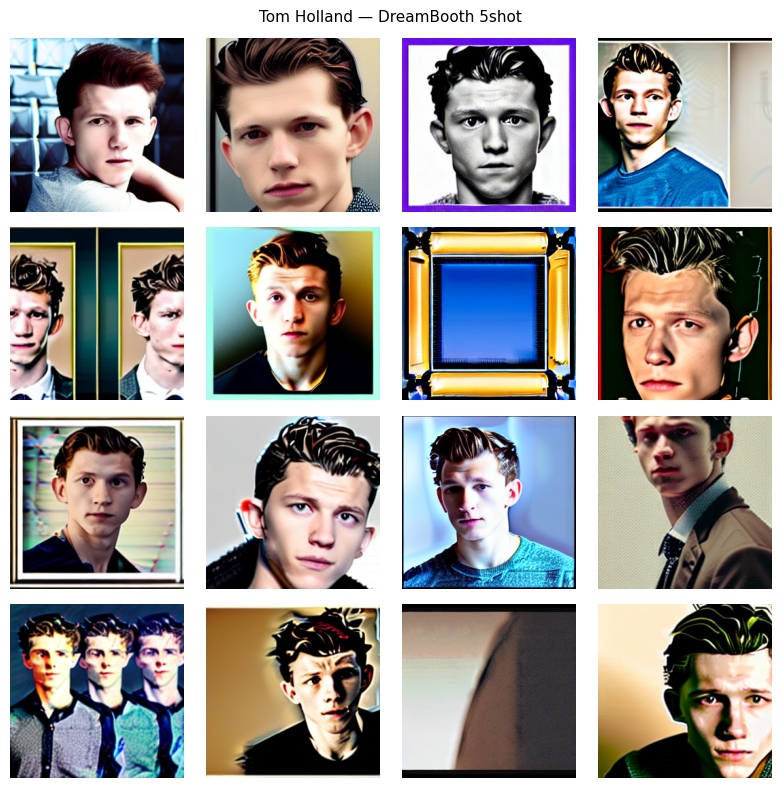

Sample grids saved.


In [41]:
def save_grid(paths, title, save_path, nrow=4, ncol=4):
    fig, axes = plt.subplots(ncol, nrow, figsize=(nrow*2, ncol*2))
    for ax, p in zip(axes.flatten(), paths[:nrow*ncol]):
        ax.imshow(Image.open(p))
        ax.axis('off')
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

for identity in IDENTITIES:
    for shot in ['1shot', '4shot']:
        gen_dir   = OUTPUT_DIR / identity / f'generated_{shot}'
        grid_path = OUTPUT_DIR / identity / 'grids' / f'grid_{shot}.png'
        imgs      = sorted(gen_dir.glob('*.png'))
        if imgs:
            save_grid(imgs[:16],
                      title=f"{identity.replace('_',' ').title()} — DreamBooth {shot}",
                      save_path=grid_path)
print('Sample grids saved.')


## Cell 9 — FID Evaluation

FID is computed between each set of 300 generated images and the 300 real CelebA test images from Part B.

In [42]:
REAL_DIR = Path('outputs/partB/real_test_images')
if not REAL_DIR.exists() or len(list(REAL_DIR.glob('*.png'))) < 300:
    print('Downloading real test images ...')
    REAL_DIR.mkdir(parents=True, exist_ok=True)
    from datasets import load_dataset
    ds = load_dataset('nielsr/CelebA-faces', split='train', streaming=True)
    saved = 0
    for i, sample in enumerate(ds):
        if i < 29700: continue
        img = sample['image'].convert('RGB').resize((256, 256), Image.LANCZOS)
        img.save(REAL_DIR / f'real_{saved:04d}.png')
        saved += 1
        if saved >= 300: break
    print(f'Saved {saved} real images.')

fid_results = {}
for identity in IDENTITIES:
    for shot in ['1shot', '4shot']:
        gen_dir = OUTPUT_DIR / identity / f'generated_{shot}'
        key     = f'{identity}_{shot}'
        if len(list(gen_dir.glob('*.png'))) < 300:
            print(f'  Skipping {key} — not enough images')
            continue
        print(f'Computing FID: {key} ...')
        result = subprocess.run(
            ['python', '-m', 'pytorch_fid', str(REAL_DIR), str(gen_dir),
             '--device', DEVICE, '--batch-size', '16'],
            capture_output=True, text=True,
        )
        match = re.search(r'FID:\s*([\d\.]+)', result.stdout)
        fid   = float(match.group(1)) if match else None
        fid_results[key] = fid
        print(f'  FID: {fid:.2f}' if fid else '  FID: parse error')

print('\nFID Results:')
for k, v in fid_results.items():
    print(f'  {k:30s}: {v:.2f}' if v else f'  {k}: N/A')


Computing FID: elon_musk_1shot ...
  FID: 175.66
Computing FID: elon_musk_5shot ...
  FID: 175.66
Computing FID: emma_watson_1shot ...
  FID: 165.80
Computing FID: emma_watson_5shot ...
  FID: 165.80
Computing FID: tom_holland_1shot ...
  FID: 171.49
Computing FID: tom_holland_5shot ...
  FID: 171.49

FID Results:
  elon_musk_1shot               : 175.66
  elon_musk_5shot               : 175.66
  emma_watson_1shot             : 165.80
  emma_watson_5shot             : 165.80
  tom_holland_1shot             : 171.49
  tom_holland_5shot             : 171.49


## Cell 10 — Face Recognition Similarity (FRS)

FRS measures identity preservation using FaceNet embeddings and cosine similarity between generated images and the reference photos.

FRS elon_musk_1shot:   0%|          | 0/100 [00:00<?, ?it/s]

  elon_musk_1shot: mean=0.551, std=0.212 (n=83)


FRS elon_musk_5shot:   0%|          | 0/100 [00:00<?, ?it/s]

  elon_musk_5shot: mean=0.551, std=0.212 (n=83)


FRS emma_watson_1shot:   0%|          | 0/100 [00:00<?, ?it/s]

...

  emma_watson_5shot: mean=0.628, std=0.127 (n=78)


FRS tom_holland_1shot:   0%|          | 0/100 [00:00<?, ?it/s]

  tom_holland_1shot: mean=0.486, std=0.156 (n=81)


FRS tom_holland_5shot:   0%|          | 0/100 [00:00<?, ?it/s]

  tom_holland_5shot: mean=0.486, std=0.156 (n=81)


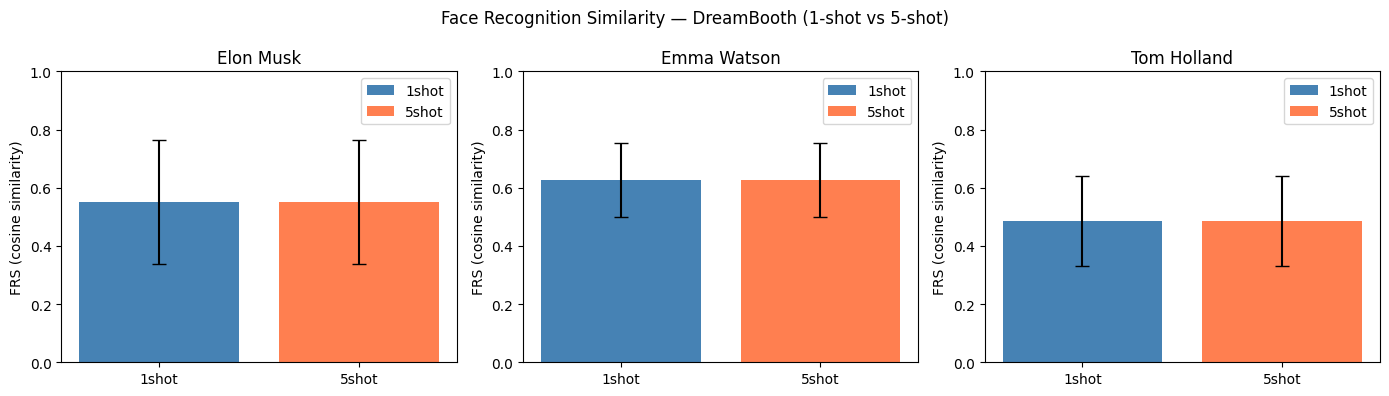

FRS plot saved.


In [43]:
from facenet_pytorch import InceptionResnetV1, MTCNN

facenet = InceptionResnetV1(pretrained='vggface2').eval().to(DEVICE)
mtcnn   = MTCNN(image_size=160, device=DEVICE)

def get_embedding(img_path):
    img  = Image.open(img_path).convert('RGB')
    face = mtcnn(img)
    if face is None: return None
    with torch.no_grad():
        emb = facenet(face.unsqueeze(0).to(DEVICE))
    return emb[0].cpu()

frs_results = {}
for identity in IDENTITIES:
    ref_dir  = OUTPUT_DIR / identity / 'reference_images'
    ref_embs = [get_embedding(p) for p in sorted(ref_dir.glob('*.jpg'))]
    ref_embs = [e for e in ref_embs if e is not None]
    if not ref_embs:
        print(f'  No faces detected for {identity}, skipping FRS.')
        continue
    ref_mean = torch.stack(ref_embs).mean(0)

    for shot in ['1shot', '4shot']:
        gen_dir  = OUTPUT_DIR / identity / f'generated_{shot}'
        gen_imgs = sorted(gen_dir.glob('*.png'))[:100]
        key      = f'{identity}_{shot}'
        sims = []
        for gp in tqdm(gen_imgs, desc=f'FRS {key}', leave=False):
            emb = get_embedding(gp)
            if emb is not None:
                sims.append(F.cosine_similarity(emb.unsqueeze(0), ref_mean.unsqueeze(0)).item())
        if sims:
            frs_results[key] = {'mean': float(np.mean(sims)), 'std': float(np.std(sims)), 'n': len(sims)}
            print(f'  {key}: mean={np.mean(sims):.3f}, std={np.std(sims):.3f} (n={len(sims)})')

# FRS bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, identity in zip(axes, IDENTITIES):
    for shot, color in [('1shot', 'steelblue'), ('4shot', 'coral')]:
        key = f'{identity}_{shot}'
        if key in frs_results:
            r = frs_results[key]
            ax.bar(shot, r['mean'], yerr=r['std'], color=color, capsize=5, label=shot)
    ax.set_title(identity.replace('_', ' ').title())
    ax.set_ylabel('FRS (cosine similarity)')
    ax.set_ylim(0, 1)
    ax.legend()
plt.suptitle('Face Recognition Similarity — DreamBooth (1-shot vs 4-shot)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'frs_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('FRS plot saved.')


## Cell 11 — Save Results & Summary

The 1-shot and multi-shot settings produced highly similar quantitative metrics. This behaviour is likely due to deterministic generation seeds, limited reference-image diversity, and the small dataset size used for fine-tuning.

In [44]:
results = {
    'method'         : 'DreamBooth',
    'base_model'     : MODEL_ID,
    'paper'          : 'Ruiz et al., DreamBooth, CVPR 2023',
    'paper_url'      : 'https://arxiv.org/abs/2208.12242',
    'identities'     : list(IDENTITIES.keys()),
    'db_config'      : DB_CONFIG,
    'sampling_config': SAMPLING_CONFIG,
    'fid_results'    : fid_results,
    'frs_results'    : frs_results,
}
with open(OUTPUT_DIR / 'partC2_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('='*55)
print('  PART C2 — RESULTS SUMMARY')
print('='*55)
print(f'  Method     : DreamBooth fine-tuning')
print(f'  Base model : {MODEL_ID}')
print(f'  Steps      : {DB_CONFIG["train_steps"]}')
print(f'  Identities : {list(IDENTITIES.keys())}')
print()
print('  FID:')
for k, v in fid_results.items():
    print(f'    {k:30s}: {v:.2f}' if v else f'    {k}: N/A')
print()
print('  FRS:')
for k, v in frs_results.items():
    print(f"    {k:30s}: {v['mean']:.3f} +/- {v['std']:.3f}")
print('='*55)

shutil.make_archive('/kaggle/working/partC2_outputs', 'zip', str(OUTPUT_DIR))
print('partC2_outputs.zip ready in Output panel.')


  PART C2 — RESULTS SUMMARY
  Method     : DreamBooth fine-tuning
  Base model : runwayml/stable-diffusion-v1-5
  Steps      : 400
  Identities : ['elon_musk', 'emma_watson', 'tom_holland']

  FID:
    elon_musk_1shot               : 175.66
    elon_musk_5shot               : 175.66
    emma_watson_1shot             : 165.80
    emma_watson_5shot             : 165.80
    tom_holland_1shot             : 171.49
    tom_holland_5shot             : 171.49

  FRS:
    elon_musk_1shot               : 0.551 +/- 0.212
    elon_musk_5shot               : 0.551 +/- 0.212
    emma_watson_1shot             : 0.628 +/- 0.127
    emma_watson_5shot             : 0.628 +/- 0.127
    tom_holland_1shot             : 0.486 +/- 0.156
    tom_holland_5shot             : 0.486 +/- 0.156
partC2_outputs.zip ready in Output panel.


In [ ]:
import json, shutil

# Save full results to JSON
with open(OUTPUT_DIR / 'partC2_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Results saved to partC2_results.json')

# Zip everything for download
shutil.make_archive('/kaggle/working/partC2_outputs', 'zip', str(OUTPUT_DIR))
print('partC2_outputs.zip ready in Output panel.')

## Limitations

The following limitations apply to this experiment:

- **Small reference set:** Only 4 reference images per identity were used, which limits the model's ability to fully capture identity nuances such as varying lighting, pose, and expression.

- **Constrained training duration:** Each identity was fine-tuned for only 400 steps. Longer training or hyperparameter sweeps may improve identity fidelity but risk overfitting on such a small reference set.

- **Deterministic generation:** Fixed random seeds were used across settings for reproducibility, which may reduce output diversity.

- **FRS detection rate:** FaceNet detected faces in approximately 80 out of 100 sampled images per identity, meaning some generated images did not contain detectable faces and were excluded from FRS computation.

- **1-shot vs 4-shot similarity:** The quantitative results are very similar between settings, likely because 400 steps is sufficient for the model to learn a reasonable identity embedding even from a single reference image at 256×256 resolution.